# Retail Intelligence Platform

# Notebook 01 — Data Understanding

---

# Objective

This notebook performs the complete Data Understanding phase of the Retail Intelligence Platform.

The notebook automatically:

* Loads every dataset
* Profiles every table
* Detects missing values
* Detects duplicates
* Validates keys
* Generates data quality reports
* Creates Excel reports
* Documents business observations

This notebook **does not clean data**.

Cleaning begins in Notebook 02.

---

# CRISP-DM Phase

Business Understanding ✅

Data Understanding ✅ (Current Notebook)

Data Preparation ⏳

Modeling ⏳

Evaluation ⏳

Deployment ⏳

---

# Notebook Workflow

```text
Import Libraries

↓

Locate Dataset

↓

Load CSV Files

↓

Dataset Inventory

↓

Table Profiling

↓

Missing Values

↓

Duplicate Analysis

↓

Primary Key Validation

↓

Relationship Validation

↓

Business Observations

↓

Export Reports
```

---

# Folder Structure Used

```text
Retail-Intelligence-Platform/

data/
    raw/
    cleaned/
    processed/

reports/

notebooks/

src/
```

---

# Expected Outputs

After execution this notebook will generate

reports/

* dataset_inventory.xlsx
* profiling_summary.xlsx
* missing_values.xlsx
* duplicate_report.xlsx
* data_quality_report.xlsx
* column_statistics.xlsx

---

# Success Criteria

This notebook is successful when

✓ Every dataset loads successfully

✓ Every table is profiled

✓ Missing values are identified

✓ Duplicate rows are identified

✓ Data types are validated

✓ Excel reports are exported

✓ Data quality summary is generated

---

# Author

Divya Kumar

Retail Intelligence Platform


In [1]:
# ======================================================
# Retail Intelligence Platform
# Notebook 01 : Data Understanding
# Import Required Libraries
# ======================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np

from datetime import datetime

# Display Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

print("="*60)
print("Retail Intelligence Platform")
print("Notebook 01 : Data Understanding")
print("="*60)

print("\nLibraries Loaded Successfully")

Retail Intelligence Platform
Notebook 01 : Data Understanding

Libraries Loaded Successfully


In [2]:
# ======================================================
# Define Project Paths
# ======================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)

print("Raw Data Folder :", RAW_DATA)
print("Reports Folder  :", REPORTS)

Raw Data Folder : c:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw
Reports Folder  : c:\Users\divya\Downloads\Retail-Intelligence-Platform\reports


In [3]:
# ======================================================
# Verify Dataset
# ======================================================

csv_files = list(RAW_DATA.glob("*.csv"))

print(f"CSV Files Found : {len(csv_files)}\n")

for file in sorted(csv_files):
    print(file.name)

CSV Files Found : 9

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [4]:
# ======================================================
# Automatically Load All CSV Files
# ======================================================

datasets = {}

print("=" * 70)
print("Loading Datasets")
print("=" * 70)

for file in sorted(RAW_DATA.glob("*.csv")):

    try:

        df = pd.read_csv(file)

        dataset_name = file.stem

        datasets[dataset_name] = df

        print(f"Loaded : {dataset_name:<40} Shape : {df.shape}")

    except Exception as e:

        print(f"Failed : {file.name}")
        print(e)

print("\n")
print("=" * 70)
print(f"Total Datasets Loaded : {len(datasets)}")
print("=" * 70)

Loading Datasets
Loaded : olist_customers_dataset                  Shape : (99441, 5)
Loaded : olist_geolocation_dataset                Shape : (1000163, 5)
Loaded : olist_order_items_dataset                Shape : (112650, 7)
Loaded : olist_order_payments_dataset             Shape : (103886, 5)
Loaded : olist_order_reviews_dataset              Shape : (99224, 7)
Loaded : olist_orders_dataset                     Shape : (99441, 8)
Loaded : olist_products_dataset                   Shape : (32951, 9)
Loaded : olist_sellers_dataset                    Shape : (3095, 4)
Loaded : product_category_name_translation        Shape : (71, 2)


Total Datasets Loaded : 9


In [5]:
# ======================================================
# Project Configuration
# ======================================================

PRIMARY_KEYS = {
    "olist_orders_dataset": "order_id",
    "olist_customers_dataset": "customer_id",
    "olist_products_dataset": "product_id",
    "olist_sellers_dataset": "seller_id",
    "olist_order_reviews_dataset": "review_id"
}

COMPOSITE_KEYS = {
    "olist_order_items_dataset": ["order_id", "order_item_id"],
    "olist_order_payments_dataset": ["order_id", "payment_sequential"]
}

RELATIONSHIPS = [
    ("olist_orders_dataset", "customer_id", "olist_customers_dataset", "customer_id"),
    ("olist_order_items_dataset", "order_id", "olist_orders_dataset", "order_id"),
    ("olist_order_items_dataset", "product_id", "olist_products_dataset", "product_id"),
    ("olist_order_items_dataset", "seller_id", "olist_sellers_dataset", "seller_id"),
    ("olist_order_payments_dataset", "order_id", "olist_orders_dataset", "order_id"),
    ("olist_order_reviews_dataset", "order_id", "olist_orders_dataset", "order_id")
]

print("Project configuration loaded successfully.")

Project configuration loaded successfully.


In [6]:
# ======================================================
# Display Dataset Names
# ======================================================

print("\nAvailable Datasets\n")

for i, name in enumerate(datasets.keys(), start=1):

    print(f"{i}. {name}")


Available Datasets

1. olist_customers_dataset
2. olist_geolocation_dataset
3. olist_order_items_dataset
4. olist_order_payments_dataset
5. olist_order_reviews_dataset
6. olist_orders_dataset
7. olist_products_dataset
8. olist_sellers_dataset
9. product_category_name_translation


In [7]:
# ======================================================
# Dataset Inventory
# ======================================================

inventory = []

for name, df in datasets.items():

    inventory.append({

        "Dataset": name,

        "Rows": df.shape[0],

        "Columns": df.shape[1],

        "Memory (MB)": round(df.memory_usage(deep=True).sum()/1024**2,2)

    })

inventory_df = pd.DataFrame(inventory)

inventory_df = inventory_df.sort_values("Dataset")

inventory_df.reset_index(drop=True, inplace=True)

inventory_df

,Dataset,Rows,Columns,Memory (MB)
0,olist_customers_dataset,99441,5,11.03
1,olist_geolocation_dataset,1000163,5,50.12
2,olist_order_items_dataset,112650,7,18.37
3,olist_order_payments_dataset,103886,5,8.11
4,olist_order_reviews_dataset,99224,7,17.84
5,olist_orders_dataset,99441,8,21.95
6,olist_products_dataset,32951,9,3.73
7,olist_sellers_dataset,3095,4,0.22
8,product_category_name_translation,71,2,0.00


In [8]:
# ======================================================
# Display Dataset Inventory
# ======================================================

print("=" * 80)
print("DATASET INVENTORY")
print("=" * 80)

display(inventory_df)

print("\nTotal Datasets :", len(inventory_df))
print("Total Rows     :", inventory_df["Rows"].sum())
print("Total Columns  :", inventory_df["Columns"].sum())

DATASET INVENTORY


,Dataset,Rows,Columns,Memory (MB)
0,olist_customers_dataset,99441,5,11.03
1,olist_geolocation_dataset,1000163,5,50.12
2,olist_order_items_dataset,112650,7,18.37
3,olist_order_payments_dataset,103886,5,8.11
4,olist_order_reviews_dataset,99224,7,17.84
5,olist_orders_dataset,99441,8,21.95
6,olist_products_dataset,32951,9,3.73
7,olist_sellers_dataset,3095,4,0.22
8,product_category_name_translation,71,2,0.00



Total Datasets : 9
Total Rows     : 1550922
Total Columns  : 52


In [9]:
# ======================================================
# Professional Dataset Profiling Function
# ======================================================

def profile_dataset(df, dataset_name):

    profile = pd.DataFrame({

        "Column": df.columns,

        "Data Type": df.dtypes.astype(str),

        "Non-Null Values": df.count().values,

        "Missing Values": df.isnull().sum().values,

        "Missing %": (
            df.isnull().sum() / len(df) * 100
        ).round(2).values,

        "Unique Values": df.nunique().values,

        "Duplicate Values": (
            len(df) - df.nunique()
        ).values

    })

    profile["Dataset"] = dataset_name

    return profile

In [10]:
# ======================================================
# Generate Profile For Every Dataset
# ======================================================

profiles = []

for name, df in datasets.items():

    print(f"Profiling : {name}")

    profile = profile_dataset(df, name)

    profiles.append(profile)

print("\nAll datasets profiled successfully.")

Profiling : olist_customers_dataset
Profiling : olist_geolocation_dataset
Profiling : olist_order_items_dataset
Profiling : olist_order_payments_dataset
Profiling : olist_order_reviews_dataset
Profiling : olist_orders_dataset
Profiling : olist_products_dataset
Profiling : olist_sellers_dataset
Profiling : product_category_name_translation

All datasets profiled successfully.


In [11]:
# ======================================================
# Combine Profiles
# ======================================================

master_profile = pd.concat(
    profiles,
    ignore_index=True
)

master_profile.head()

,Column,Data Type,Non-Null Values,Missing Values,Missing %,Unique Values,Duplicate Values,Dataset
0,customer_id,str,99441,0,0.0,99441,0,olist_customers_dataset
1,customer_unique_id,str,99441,0,0.0,96096,3345,olist_customers_dataset
2,customer_zip_code_prefix,int64,99441,0,0.0,14994,84447,olist_customers_dataset
3,customer_city,str,99441,0,0.0,4119,95322,olist_customers_dataset
4,customer_state,str,99441,0,0.0,27,99414,olist_customers_dataset


In [12]:
# ======================================================
# Profiling Summary
# ======================================================

print("="*60)

print("MASTER PROFILE")

print("="*60)

print("Total Columns Profiled :", len(master_profile))

print("Datasets              :", master_profile["Dataset"].nunique())

print("Columns With Missing  :",
      (master_profile["Missing Values"] > 0).sum())

print("Complete Columns      :",
      (master_profile["Missing Values"] == 0).sum())

print("="*60)

MASTER PROFILE
Total Columns Profiled : 52
Datasets              : 9
Columns With Missing  : 13
Complete Columns      : 39


In [13]:
# ======================================================
# Master Profile
# ======================================================

display(master_profile)

,Column,Data Type,Non-Null Values,Missing Values,Missing %,Unique Values,Duplicate Values,Dataset
0,customer_id,str,99441,0,0.00,99441,0,olist_customers_dataset
1,customer_unique_id,str,99441,0,0.00,96096,3345,olist_customers_dataset
2,customer_zip_code_prefix,int64,99441,0,0.00,14994,84447,olist_customers_dataset
3,customer_city,str,99441,0,0.00,4119,95322,olist_customers_dataset
4,customer_state,str,99441,0,0.00,27,99414,olist_customers_dataset
5,geolocation_zip_code_prefix,int64,1000163,0,0.00,19015,981148,olist_geolocation_dataset
6,geolocation_lat,float64,1000163,0,0.00,717360,282803,olist_geolocation_dataset
7,geolocation_lng,float64,1000163,0,0.00,717613,282550,olist_geolocation_dataset
8,geolocation_city,str,1000163,0,0.00,8011,992152,olist_geolocation_dataset
9,geolocation_state,str,1000163,0,0.00,27,1000136,olist_geolocation_dataset


In [14]:
# ======================================================
# Missing Value Analysis
# ======================================================

missing_summary = []

for name, df in datasets.items():

    total_rows = len(df)

    for column in df.columns:

        missing = df[column].isnull().sum()

        missing_summary.append({

            "Dataset": name,

            "Column": column,

            "Missing Values": missing,

            "Missing %": round((missing / total_rows) * 100, 2)

        })

missing_df = pd.DataFrame(missing_summary)

missing_df = missing_df.sort_values(

    by="Missing Values",

    ascending=False

)

missing_df.reset_index(drop=True, inplace=True)

display(missing_df.head(20))

,Dataset,Column,Missing Values,Missing %
0,olist_order_reviews_dataset,review_comment_title,87656,88.34
1,olist_order_reviews_dataset,review_comment_message,58247,58.70
2,olist_orders_dataset,order_delivered_customer_date,2965,2.98
3,olist_orders_dataset,order_delivered_carrier_date,1783,1.79
4,olist_products_dataset,product_name_lenght,610,1.85
5,olist_products_dataset,product_category_name,610,1.85
6,olist_products_dataset,product_photos_qty,610,1.85
7,olist_products_dataset,product_description_lenght,610,1.85
8,olist_orders_dataset,order_approved_at,160,0.16
9,olist_products_dataset,product_weight_g,2,0.01


In [15]:
# ======================================================
# Missing Value Summary
# ======================================================

print("="*60)

print("MISSING VALUE SUMMARY")

print("="*60)

columns_with_missing = (missing_df["Missing Values"] > 0).sum()

total_missing = missing_df["Missing Values"].sum()

print(f"Columns with Missing Values : {columns_with_missing}")

print(f"Total Missing Values        : {total_missing:,}")

print("="*60)

MISSING VALUE SUMMARY
Columns with Missing Values : 13
Total Missing Values        : 153,259


In [16]:
# ======================================================
# Missing Values by Dataset
# ======================================================

dataset_missing = (

    missing_df

    .groupby("Dataset")["Missing Values"]

    .sum()

    .reset_index()

    .sort_values(

        "Missing Values",

        ascending=False

    )

)

display(dataset_missing)

,Dataset,Missing Values
4,olist_order_reviews_dataset,145903
5,olist_orders_dataset,4908
6,olist_products_dataset,2448
0,olist_customers_dataset,0
1,olist_geolocation_dataset,0
3,olist_order_payments_dataset,0
2,olist_order_items_dataset,0
7,olist_sellers_dataset,0
8,product_category_name_translation,0


In [17]:
# ======================================================
# Missing Percentage by Dataset
# ======================================================

missing_percent = (

    missing_df

    .groupby("Dataset")["Missing %"]

    .mean()

    .round(2)

    .reset_index()

)

display(missing_percent)

,Dataset,Missing %
0,olist_customers_dataset,0.00
1,olist_geolocation_dataset,0.00
2,olist_order_items_dataset,0.00
3,olist_order_payments_dataset,0.00
4,olist_order_reviews_dataset,21.01
5,olist_orders_dataset,0.62
6,olist_products_dataset,0.83
7,olist_sellers_dataset,0.00
8,product_category_name_translation,0.00


In [18]:
# ======================================================
# Show Only Columns Having Missing Values
# ======================================================

missing_columns = missing_df[

    missing_df["Missing Values"] > 0

]

display(missing_columns)

,Dataset,Column,Missing Values,Missing %
0,olist_order_reviews_dataset,review_comment_title,87656,88.34
1,olist_order_reviews_dataset,review_comment_message,58247,58.70
2,olist_orders_dataset,order_delivered_customer_date,2965,2.98
3,olist_orders_dataset,order_delivered_carrier_date,1783,1.79
4,olist_products_dataset,product_name_lenght,610,1.85
5,olist_products_dataset,product_category_name,610,1.85
6,olist_products_dataset,product_photos_qty,610,1.85
7,olist_products_dataset,product_description_lenght,610,1.85
8,olist_orders_dataset,order_approved_at,160,0.16
9,olist_products_dataset,product_weight_g,2,0.01


In [19]:
# ======================================================
# Automatic Missing Value Observations
# ======================================================

print("="*70)

print("DATA QUALITY OBSERVATIONS")

print("="*70)

for _, row in missing_columns.iterrows():

    print(

        f"{row['Dataset']} -> "

        f"{row['Column']} has "

        f"{row['Missing Values']} missing values "

        f"({row['Missing %']}%)"

    )

DATA QUALITY OBSERVATIONS
olist_order_reviews_dataset -> review_comment_title has 87656 missing values (88.34%)
olist_order_reviews_dataset -> review_comment_message has 58247 missing values (58.7%)
olist_orders_dataset -> order_delivered_customer_date has 2965 missing values (2.98%)
olist_orders_dataset -> order_delivered_carrier_date has 1783 missing values (1.79%)
olist_products_dataset -> product_name_lenght has 610 missing values (1.85%)
olist_products_dataset -> product_category_name has 610 missing values (1.85%)
olist_products_dataset -> product_photos_qty has 610 missing values (1.85%)
olist_products_dataset -> product_description_lenght has 610 missing values (1.85%)
olist_orders_dataset -> order_approved_at has 160 missing values (0.16%)
olist_products_dataset -> product_weight_g has 2 missing values (0.01%)
olist_products_dataset -> product_width_cm has 2 missing values (0.01%)
olist_products_dataset -> product_length_cm has 2 missing values (0.01%)
olist_products_dataset -

In [20]:
# ======================================================
# Missing Value Quality Score
# ======================================================

total_cells = 0

missing_cells = 0

for df in datasets.values():

    total_cells += df.shape[0] * df.shape[1]

    missing_cells += df.isnull().sum().sum()

quality_score = (

    (1 - missing_cells / total_cells)

    * 100

)

print("="*60)

print("DATA COMPLETENESS SCORE")

print("="*60)

print(f"Total Cells      : {total_cells:,}")

print(f"Missing Cells    : {missing_cells:,}")

print(f"Completeness     : {quality_score:.2f}%")

print("="*60)

DATA COMPLETENESS SCORE
Total Cells      : 8,605,177
Missing Cells    : 153,259
Completeness     : 98.22%


In [21]:
# ======================================================
# Duplicate Row Detection
# ======================================================

duplicate_summary = []

for name, df in datasets.items():

    duplicate_rows = df.duplicated().sum()

    duplicate_summary.append({

        "Dataset": name,

        "Total Rows": len(df),

        "Duplicate Rows": duplicate_rows,

        "Duplicate %": round(
            duplicate_rows / len(df) * 100,
            4
        )

    })

duplicate_df = pd.DataFrame(duplicate_summary)

duplicate_df = duplicate_df.sort_values(
    "Duplicate Rows",
    ascending=False
)

display(duplicate_df)

,Dataset,Total Rows,Duplicate Rows,Duplicate %
1,olist_geolocation_dataset,1000163,261831,26.1788
0,olist_customers_dataset,99441,0,0.0000
2,olist_order_items_dataset,112650,0,0.0000
3,olist_order_payments_dataset,103886,0,0.0000
4,olist_order_reviews_dataset,99224,0,0.0000
5,olist_orders_dataset,99441,0,0.0000
6,olist_products_dataset,32951,0,0.0000
7,olist_sellers_dataset,3095,0,0.0000
8,product_category_name_translation,71,0,0.0000


In [22]:
# ======================================================
# Duplicate Summary
# ======================================================

print("="*60)

print("DUPLICATE ANALYSIS")

print("="*60)

print(f"Datasets Checked : {len(duplicate_df)}")

print(
    f"Datasets With Duplicates : "
    f"{(duplicate_df['Duplicate Rows'] > 0).sum()}"
)

print(
    f"Total Duplicate Rows : "
    f"{duplicate_df['Duplicate Rows'].sum():,}"
)

print("="*60)

DUPLICATE ANALYSIS
Datasets Checked : 9
Datasets With Duplicates : 1
Total Duplicate Rows : 261,831


In [23]:
# ======================================================
# Primary Key Validation
# ======================================================

primary_keys = {

    "olist_orders_dataset": "order_id",

    "olist_customers_dataset": "customer_id",

    "olist_products_dataset": "product_id",

    "olist_sellers_dataset": "seller_id",

    "olist_order_reviews_dataset": "review_id"

}

pk_validation = []

for dataset, key in primary_keys.items():

    df = datasets[dataset]

    duplicate_keys = df[key].duplicated().sum()

    pk_validation.append({

        "Dataset": dataset,

        "Primary Key": key,

        "Duplicate Keys": duplicate_keys,

        "Status": (
            "PASS"
            if duplicate_keys == 0
            else "FAIL"
        )

    })

pk_validation_df = pd.DataFrame(pk_validation)

display(pk_validation_df)

,Dataset,Primary Key,Duplicate Keys,Status
0,olist_orders_dataset,order_id,0,PASS
1,olist_customers_dataset,customer_id,0,PASS
2,olist_products_dataset,product_id,0,PASS
3,olist_sellers_dataset,seller_id,0,PASS
4,olist_order_reviews_dataset,review_id,814,FAIL


In [24]:
# ======================================================
# Composite Key Validation
# ======================================================

composite_keys = {

    "olist_order_items_dataset": [
        "order_id",
        "order_item_id"
    ],

    "olist_order_payments_dataset": [
        "order_id",
        "payment_sequential"
    ]

}

composite_results = []

for dataset, keys in composite_keys.items():

    df = datasets[dataset]

    duplicates = df.duplicated(
        subset=keys
    ).sum()

    composite_results.append({

        "Dataset": dataset,

        "Composite Key": ", ".join(keys),

        "Duplicate Keys": duplicates,

        "Status": (
            "PASS"
            if duplicates == 0
            else "FAIL"
        )

    })

composite_df = pd.DataFrame(composite_results)

display(composite_df)

,Dataset,Composite Key,Duplicate Keys,Status
0,olist_order_items_dataset,"order_id, order_item_id",0,PASS
1,olist_order_payments_dataset,"order_id, payment_sequential",0,PASS


In [25]:
# ======================================================
# Show Duplicate Samples
# ======================================================

for name, df in datasets.items():

    duplicates = df[df.duplicated()]

    if len(duplicates) > 0:

        print("="*70)

        print(name)

        print("="*70)

        display(duplicates.head())

olist_geolocation_dataset


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP


In [26]:
# ======================================================
# Data Integrity Report
# ======================================================

print("="*60)

print("DATA INTEGRITY REPORT")

print("="*60)

duplicate_tables = duplicate_df[
    duplicate_df["Duplicate Rows"] > 0
]

if duplicate_tables.empty:

    print("No duplicate rows detected.")

else:

    print("Datasets with duplicate rows:\n")

    display(duplicate_tables)

print("\nPrimary Key Validation")

display(pk_validation_df)

print("\nComposite Key Validation")

display(composite_df)

DATA INTEGRITY REPORT
Datasets with duplicate rows:



,Dataset,Total Rows,Duplicate Rows,Duplicate %
1,olist_geolocation_dataset,1000163,261831,26.1788



Primary Key Validation


,Dataset,Primary Key,Duplicate Keys,Status
0,olist_orders_dataset,order_id,0,PASS
1,olist_customers_dataset,customer_id,0,PASS
2,olist_products_dataset,product_id,0,PASS
3,olist_sellers_dataset,seller_id,0,PASS
4,olist_order_reviews_dataset,review_id,814,FAIL



Composite Key Validation


,Dataset,Composite Key,Duplicate Keys,Status
0,olist_order_items_dataset,"order_id, order_item_id",0,PASS
1,olist_order_payments_dataset,"order_id, payment_sequential",0,PASS


In [27]:
# ======================================================
# Data Integrity Score
# ======================================================

total_rows = duplicate_df["Total Rows"].sum()

duplicate_rows = duplicate_df["Duplicate Rows"].sum()

integrity_score = (
    (1 - duplicate_rows / total_rows)
    * 100
)

print("="*60)

print("DATA INTEGRITY SCORE")

print("="*60)

print(f"Total Rows      : {total_rows:,}")

print(f"Duplicate Rows  : {duplicate_rows:,}")

print(f"Integrity Score : {integrity_score:.2f}%")

print("="*60)

DATA INTEGRITY SCORE
Total Rows      : 1,550,922
Duplicate Rows  : 261,831
Integrity Score : 83.12%


In [28]:
# ======================================================
# Data Integrity Score
# ======================================================

total_rows = duplicate_df["Total Rows"].sum()

duplicate_rows = duplicate_df["Duplicate Rows"].sum()

integrity_score = (
    (1 - duplicate_rows / total_rows)
    * 100
)

print("="*60)

print("DATA INTEGRITY SCORE")

print("="*60)

print(f"Total Rows      : {total_rows:,}")

print(f"Duplicate Rows  : {duplicate_rows:,}")

print(f"Integrity Score : {integrity_score:.2f}%")

print("="*60)

DATA INTEGRITY SCORE
Total Rows      : 1,550,922
Duplicate Rows  : 261,831
Integrity Score : 83.12%


In [29]:
# ======================================================
# Foreign Key Relationships
# ======================================================

relationships = [

    (
        "olist_orders_dataset",
        "customer_id",
        "olist_customers_dataset",
        "customer_id"
    ),

    (
        "olist_order_items_dataset",
        "order_id",
        "olist_orders_dataset",
        "order_id"
    ),

    (
        "olist_order_items_dataset",
        "product_id",
        "olist_products_dataset",
        "product_id"
    ),

    (
        "olist_order_items_dataset",
        "seller_id",
        "olist_sellers_dataset",
        "seller_id"
    ),

    (
        "olist_order_payments_dataset",
        "order_id",
        "olist_orders_dataset",
        "order_id"
    ),

    (
        "olist_order_reviews_dataset",
        "order_id",
        "olist_orders_dataset",
        "order_id"
    )

]

print(f"Relationships Loaded : {len(relationships)}")

Relationships Loaded : 6


In [30]:
# ======================================================
# Referential Integrity Validation
# ======================================================

relationship_results = []

for child_table, child_key, parent_table, parent_key in relationships:

    child_df = datasets[child_table]

    parent_df = datasets[parent_table]

    orphan_records = (

        ~child_df[child_key]

        .isin(parent_df[parent_key])

    ).sum()

    relationship_results.append({

        "Child Table": child_table,

        "Foreign Key": child_key,

        "Parent Table": parent_table,

        "Primary Key": parent_key,

        "Child Rows": len(child_df),

        "Parent Rows": len(parent_df),

        "Orphan Records": orphan_records,

        "Status": "PASS"

        if orphan_records == 0

        else "FAIL"

    })

relationship_df = pd.DataFrame(

    relationship_results

)

display(relationship_df)

,Child Table,Foreign Key,Parent Table,Primary Key,Child Rows,Parent Rows,Orphan Records,Status
0,olist_orders_dataset,customer_id,olist_customers_dataset,customer_id,99441,99441,0,PASS
1,olist_order_items_dataset,order_id,olist_orders_dataset,order_id,112650,99441,0,PASS
2,olist_order_items_dataset,product_id,olist_products_dataset,product_id,112650,32951,0,PASS
3,olist_order_items_dataset,seller_id,olist_sellers_dataset,seller_id,112650,3095,0,PASS
4,olist_order_payments_dataset,order_id,olist_orders_dataset,order_id,103886,99441,0,PASS
5,olist_order_reviews_dataset,order_id,olist_orders_dataset,order_id,99224,99441,0,PASS


In [31]:
# ======================================================
# Referential Integrity Dashboard
# ======================================================

print("="*60)

print("REFERENTIAL INTEGRITY REPORT")

print("="*60)

total_relationships = len(relationship_df)

passed = (

    relationship_df["Status"]

    == "PASS"

).sum()

failed = (

    relationship_df["Status"]

    == "FAIL"

).sum()

print(f"Relationships Checked : {total_relationships}")

print(f"Passed                : {passed}")

print(f"Failed                : {failed}")

print("="*60)

REFERENTIAL INTEGRITY REPORT
Relationships Checked : 6
Passed                : 6
Failed                : 0


In [32]:
# ======================================================
# Failed Relationships
# ======================================================

failed_relationships = relationship_df[

    relationship_df["Status"] == "FAIL"

]

if failed_relationships.empty:

    print("No orphan records detected.")

else:

    display(failed_relationships)

No orphan records detected.


In [33]:
# ======================================================
# Show Sample Orphan Records
# ======================================================

for child_table, child_key, parent_table, parent_key in relationships:

    child_df = datasets[child_table]

    parent_df = datasets[parent_table]

    orphan = child_df[

        ~child_df[child_key]

        .isin(parent_df[parent_key])

    ]

    if len(orphan) > 0:

        print("="*70)

        print(child_table)

        print("="*70)

        display(orphan.head())

In [34]:
# ======================================================
# Referential Integrity Score
# ======================================================

total_child_rows = relationship_df["Child Rows"].sum()

total_orphans = relationship_df["Orphan Records"].sum()

integrity_score = (

    (1 - total_orphans / total_child_rows)

    * 100

)

print("="*60)

print("REFERENTIAL INTEGRITY SCORE")

print("="*60)

print(f"Rows Checked     : {total_child_rows:,}")

print(f"Orphan Records   : {total_orphans:,}")

print(f"Integrity Score  : {integrity_score:.2f}%")

print("="*60)

REFERENTIAL INTEGRITY SCORE
Rows Checked     : 640,501
Orphan Records   : 0
Integrity Score  : 100.00%


In [35]:
# ======================================================
# Business Observations
# ======================================================

print("="*70)

print("BUSINESS OBSERVATIONS")

print("="*70)

for _, row in relationship_df.iterrows():

    if row["Status"] == "PASS":

        print(

            f"✓ {row['Child Table']} "

            f"maintains referential integrity "

            f"with {row['Parent Table']}."

        )

    else:

        print(

            f"⚠ {row['Child Table']} "

            f"contains {row['Orphan Records']} "

            f"orphan records."

        )

BUSINESS OBSERVATIONS
✓ olist_orders_dataset maintains referential integrity with olist_customers_dataset.
✓ olist_order_items_dataset maintains referential integrity with olist_orders_dataset.
✓ olist_order_items_dataset maintains referential integrity with olist_products_dataset.
✓ olist_order_items_dataset maintains referential integrity with olist_sellers_dataset.
✓ olist_order_payments_dataset maintains referential integrity with olist_orders_dataset.
✓ olist_order_reviews_dataset maintains referential integrity with olist_orders_dataset.


In [36]:
# ======================================================
# Data Type Validation Engine
# ======================================================

datatype_summary = []

for dataset_name, df in datasets.items():

    for column in df.columns:

        datatype_summary.append({
            "Dataset": dataset_name,
            "Column": column,
            "Data Type": str(df[column].dtype),
            "Memory Usage (KB)": round(df[column].memory_usage(deep=True)/1024, 2),
            "Null Values": int(df[column].isnull().sum()),
            "Unique Values": int(df[column].nunique())
        })

datatype_df = pd.DataFrame(datatype_summary)

display(datatype_df.head())

,Dataset,Column,Data Type,Memory Usage (KB),Null Values,Unique Values
0,olist_customers_dataset,customer_id,str,3884.54,0,99441
1,olist_customers_dataset,customer_unique_id,str,3884.54,0,96096
2,olist_customers_dataset,customer_zip_code_prefix,int64,777.01,0,14994
3,olist_customers_dataset,customer_city,str,1781.57,0,4119
4,olist_customers_dataset,customer_state,str,971.23,0,27


In [37]:
# ======================================================
# Data Type Summary
# ======================================================

print("="*70)
print("DATA TYPE SUMMARY")
print("="*70)

summary = datatype_df.groupby("Data Type").size().reset_index(name="Columns")

display(summary)

print(f"\nTotal Columns : {len(datatype_df)}")

DATA TYPE SUMMARY


,Data Type,Columns
0,float64,12
1,int64,7
2,str,33



Total Columns : 52


In [38]:
# ======================================================
# Detect Date Columns
# ======================================================

date_columns = []

for dataset_name, df in datasets.items():

    for column in df.columns:

        column_lower = column.lower()

        if any(keyword in column_lower for keyword in [
            "date",
            "time",
            "timestamp"
        ]):

            date_columns.append({
                "Dataset": dataset_name,
                "Column": column
            })

date_columns_df = pd.DataFrame(date_columns)

display(date_columns_df)

,Dataset,Column
0,olist_order_items_dataset,shipping_limit_date
1,olist_order_reviews_dataset,review_creation_date
2,olist_order_reviews_dataset,review_answer_timestamp
3,olist_orders_dataset,order_purchase_timestamp
4,olist_orders_dataset,order_delivered_carrier_date
5,olist_orders_dataset,order_delivered_customer_date
6,olist_orders_dataset,order_estimated_delivery_date


In [39]:
# ======================================================
# Validate Date Columns
# ======================================================

date_validation = []

for _, row in date_columns_df.iterrows():

    dataset = row["Dataset"]
    column = row["Column"]

    df = datasets[dataset]

    converted = pd.to_datetime(
        df[column],
        errors="coerce"
    )

    failed = converted.isna().sum() - df[column].isna().sum()

    date_validation.append({

        "Dataset": dataset,
        "Column": column,
        "Conversion Errors": max(0, failed),
        "Status": "PASS" if failed == 0 else "CHECK"

    })

date_validation_df = pd.DataFrame(date_validation)

display(date_validation_df)

,Dataset,Column,Conversion Errors,Status
0,olist_order_items_dataset,shipping_limit_date,0,PASS
1,olist_order_reviews_dataset,review_creation_date,0,PASS
2,olist_order_reviews_dataset,review_answer_timestamp,0,PASS
3,olist_orders_dataset,order_purchase_timestamp,0,PASS
4,olist_orders_dataset,order_delivered_carrier_date,0,PASS
5,olist_orders_dataset,order_delivered_customer_date,0,PASS
6,olist_orders_dataset,order_estimated_delivery_date,0,PASS


In [40]:
# ======================================================
# Convert Date Columns
# ======================================================

for _, row in date_columns_df.iterrows():

    dataset = row["Dataset"]
    column = row["Column"]

    datasets[dataset][column] = pd.to_datetime(

        datasets[dataset][column],

        errors="coerce"

    )

print("All detected date columns converted successfully.")

All detected date columns converted successfully.


In [41]:
# ======================================================
# Validate Order Status Values
# ======================================================

EXPECTED_STATUS = {

    "approved",
    "canceled",
    "created",
    "delivered",
    "invoiced",
    "processing",
    "shipped",
    "unavailable"

}

orders = datasets["olist_orders_dataset"]

actual_status = set(

    orders["order_status"]

    .dropna()

    .unique()

)

unexpected = actual_status - EXPECTED_STATUS

print("="*70)
print("ORDER STATUS VALIDATION")
print("="*70)

print("Expected Values :", sorted(EXPECTED_STATUS))
print("\nActual Values   :", sorted(actual_status))

if len(unexpected) == 0:

    print("\n✅ PASS : No unexpected status values found.")

else:

    print("\n⚠ Unexpected Status Values:")

    print(sorted(unexpected))

ORDER STATUS VALIDATION
Expected Values : ['approved', 'canceled', 'created', 'delivered', 'invoiced', 'processing', 'shipped', 'unavailable']

Actual Values   : ['approved', 'canceled', 'created', 'delivered', 'invoiced', 'processing', 'shipped', 'unavailable']

✅ PASS : No unexpected status values found.


In [42]:
# ======================================================
# Data Validation Dashboard
# ======================================================

print("="*70)
print("DATA VALIDATION DASHBOARD")
print("="*70)

print(f"Datasets Loaded            : {len(datasets)}")
print(f"Columns Profiled           : {len(datatype_df)}")
print(f"Date Columns              : {len(date_columns_df)}")
print(f"Relationships Validated   : {len(relationship_df)}")
print(f"Primary Keys Validated    : {len(pk_validation_df)}")
print(f"Composite Keys Validated  : {len(composite_df)}")

print("="*70)

DATA VALIDATION DASHBOARD
Datasets Loaded            : 9
Columns Profiled           : 52
Date Columns              : 7
Relationships Validated   : 6
Primary Keys Validated    : 5
Composite Keys Validated  : 2


In [43]:
# ======================================================
# Executive Data Quality Score
# ======================================================

# Completeness Score
completeness_score = round(quality_score, 2)

# Integrity Score
referential_score = round(integrity_score, 2)

# Duplicate Score
duplicate_score = round(
    (1 - duplicate_df["Duplicate Rows"].sum() /
     duplicate_df["Total Rows"].sum()) * 100,
    2
)

# Primary Key Score
pk_score = round(
    (
        (pk_validation_df["Status"] == "PASS").sum()
        / len(pk_validation_df)
    ) * 100,
    2
)

overall_score = round(

    (
        completeness_score +
        referential_score +
        duplicate_score +
        pk_score

    ) / 4,

    2

)

scorecard = pd.DataFrame({

    "Metric": [

        "Completeness",
        "Duplicate Integrity",
        "Referential Integrity",
        "Primary Key Integrity",
        "Overall Score"

    ],

    "Score": [

        completeness_score,
        duplicate_score,
        referential_score,
        pk_score,
        overall_score

    ]

})

display(scorecard)

,Metric,Score
0,Completeness,98.22
1,Duplicate Integrity,83.12
2,Referential Integrity,100.00
3,Primary Key Integrity,80.00
4,Overall Score,90.34


In [44]:
# ======================================================
# Dataset Health Score
# ======================================================

health = []

for name, df in datasets.items():

    total_cells = df.shape[0] * df.shape[1]

    missing = df.isnull().sum().sum()

    duplicates = df.duplicated().sum()

    health_score = (

        100

        - (missing / total_cells) * 100

        - (duplicates / len(df)) * 100

    )

    health.append({

        "Dataset": name,

        "Health Score":

            round(max(0, health_score), 2)

    })

health_df = pd.DataFrame(health)

health_df = health_df.sort_values(

    "Health Score",

    ascending=False

)

display(health_df)

,Dataset,Health Score
0,olist_customers_dataset,100.00
2,olist_order_items_dataset,100.00
3,olist_order_payments_dataset,100.00
7,olist_sellers_dataset,100.00
8,product_category_name_translation,100.00
5,olist_orders_dataset,99.38
6,olist_products_dataset,99.17
4,olist_order_reviews_dataset,78.99
1,olist_geolocation_dataset,73.82


In [45]:
# ======================================================
# Dataset Risk Classification
# ======================================================

def classify(score):

    if score >= 98:
        return "🟢 Excellent"

    elif score >= 95:
        return "🟡 Good"

    elif score >= 90:
        return "🟠 Moderate"

    else:
        return "🔴 Needs Attention"

health_df["Risk"] = health_df["Health Score"].apply(classify)

display(health_df)

,Dataset,Health Score,Risk
0,olist_customers_dataset,100.00,🟢 Excellent
2,olist_order_items_dataset,100.00,🟢 Excellent
3,olist_order_payments_dataset,100.00,🟢 Excellent
7,olist_sellers_dataset,100.00,🟢 Excellent
8,product_category_name_translation,100.00,🟢 Excellent
5,olist_orders_dataset,99.38,🟢 Excellent
6,olist_products_dataset,99.17,🟢 Excellent
4,olist_order_reviews_dataset,78.99,🔴 Needs Attention
1,olist_geolocation_dataset,73.82,🔴 Needs Attention


In [46]:
# ======================================================
# Executive Dashboard (Production Version)
# ======================================================

required_variables = [
    "datasets",
    "datatype_df",
    "relationship_df",
    "pk_validation_df",
    "composite_df",
    "overall_score",
    "completeness_score",
    "referential_score",
    "duplicate_score",
    "pk_score"
]

missing = [v for v in required_variables if v not in globals()]

if missing:

    print("="*70)
    print("ERROR : Missing Required Variables")
    print("="*70)

    print("\nRun the previous sections first.\n")

    print("Missing Variables:")

    for v in missing:
        print(f" - {v}")

else:

    print("="*70)
    print("EXECUTIVE DATA QUALITY DASHBOARD")
    print("="*70)

    print(f"Datasets Profiled           : {len(datasets)}")
    print(f"Columns Profiled            : {len(datatype_df)}")
    print(f"Relationships Validated     : {len(relationship_df)}")
    print(f"Primary Keys Validated      : {len(pk_validation_df)}")
    print(f"Composite Keys Validated    : {len(composite_df)}")

    print("-"*70)

    print(f"Overall Data Quality Score  : {overall_score:.2f}%")
    print(f"Completeness Score          : {completeness_score:.2f}%")
    print(f"Referential Integrity Score : {referential_score:.2f}%")
    print(f"Duplicate Integrity Score   : {duplicate_score:.2f}%")
    print(f"Primary Key Score           : {pk_score:.2f}%")

    print("="*70)

EXECUTIVE DATA QUALITY DASHBOARD
Datasets Profiled           : 9
Columns Profiled            : 52
Relationships Validated     : 6
Primary Keys Validated      : 5
Composite Keys Validated    : 2
----------------------------------------------------------------------
Overall Data Quality Score  : 90.34%
Completeness Score          : 98.22%
Referential Integrity Score : 100.00%
Duplicate Integrity Score   : 83.12%
Primary Key Score           : 80.00%


In [47]:
# ======================================================
# Executive Business Recommendations
# ======================================================

print("="*70)
print("EXECUTIVE BUSINESS RECOMMENDATIONS")
print("="*70)

recommendations = []

# ---------- Overall Score ----------
if "overall_score" in globals():

    if overall_score >= 98:
        recommendations.append(
            "Overall dataset quality is excellent and suitable for analytics."
        )

    elif overall_score >= 95:
        recommendations.append(
            "Dataset quality is good. Minor improvements are recommended."
        )

    else:
        recommendations.append(
            "Dataset requires additional validation before business reporting."
        )

# ---------- Missing Values ----------
if "missing_df" in globals():

    missing_columns = (
        missing_df["Missing Values"] > 0
    ).sum()

    if missing_columns > 0:

        recommendations.append(

            f"Review {missing_columns} columns containing missing values."

        )

# ---------- Duplicate Rows ----------
if "duplicate_df" in globals():

    duplicate_rows = duplicate_df["Duplicate Rows"].sum()

    if duplicate_rows > 0:

        recommendations.append(

            f"Investigate {duplicate_rows:,} duplicate rows before KPI calculations."

        )

# ---------- Referential Integrity ----------
if "relationship_df" in globals():

    failed_relationships = (

        relationship_df["Status"] == "FAIL"

    ).sum()

    if failed_relationships > 0:

        recommendations.append(

            f"Resolve {failed_relationships} failed table relationships."

        )

# ---------- Primary Keys ----------
if "pk_validation_df" in globals():

    failed_pk = (

        pk_validation_df["Status"] == "FAIL"

    ).sum()

    if failed_pk > 0:

        recommendations.append(

            f"Investigate {failed_pk} primary key validation failures."

        )

# ---------- Default ----------
if len(recommendations) == 0:

    recommendations.append(

        "No major data quality issues detected."

    )

# ---------- Display ----------

for i, rec in enumerate(recommendations, start=1):

    print(f"{i}. {rec}")

print("="*70)

EXECUTIVE BUSINESS RECOMMENDATIONS
1. Dataset requires additional validation before business reporting.
2. Review 13 columns containing missing values.
3. Investigate 261,831 duplicate rows before KPI calculations.
4. Investigate 1 primary key validation failures.


In [48]:
# ======================================================
# Executive Summary Report
# ======================================================

print("=" * 70)
print("EXECUTIVE SUMMARY REPORT")
print("=" * 70)

# ---------- Safe Variable Checks ----------

datasets_count = len(datasets) if "datasets" in globals() else 0
columns_count = len(datatype_df) if "datatype_df" in globals() else 0
relationships_count = len(relationship_df) if "relationship_df" in globals() else 0
pk_count = len(pk_validation_df) if "pk_validation_df" in globals() else 0
composite_count = len(composite_df) if "composite_df" in globals() else 0

overall = overall_score if "overall_score" in globals() else None
completeness = completeness_score if "completeness_score" in globals() else None
duplicate = duplicate_score if "duplicate_score" in globals() else None
referential = referential_score if "referential_score" in globals() else None
pk = pk_score if "pk_score" in globals() else None

# ---------- Build Summary ----------

executive_summary = pd.DataFrame({

    "Metric":[

        "Datasets Loaded",
        "Columns Profiled",
        "Relationships Validated",
        "Primary Keys Validated",
        "Composite Keys Validated",
        "Overall Data Quality",
        "Completeness",
        "Duplicate Integrity",
        "Referential Integrity",
        "Primary Key Integrity"

    ],

    "Value":[

        datasets_count,
        columns_count,
        relationships_count,
        pk_count,
        composite_count,
        overall,
        completeness,
        duplicate,
        referential,
        pk

    ]

})

display(executive_summary)

print("\nSummary Generated Successfully.")
print("=" * 70)

EXECUTIVE SUMMARY REPORT


,Metric,Value
0,Datasets Loaded,9.00
1,Columns Profiled,52.00
2,Relationships Validated,6.00
3,Primary Keys Validated,5.00
4,Composite Keys Validated,2.00
5,Overall Data Quality,90.34
6,Completeness,98.22
7,Duplicate Integrity,83.12
8,Referential Integrity,100.00
9,Primary Key Integrity,80.00



Summary Generated Successfully.


In [49]:
# ======================================================
# Notebook Completion
# ======================================================

print("="*70)
print("NOTEBOOK 01 COMPLETED SUCCESSFULLY")
print("="*70)

print("Completed Modules")

print("✓ Dataset Inventory")
print("✓ Data Profiling")
print("✓ Missing Value Analysis")
print("✓ Duplicate Analysis")
print("✓ Primary Key Validation")
print("✓ Composite Key Validation")
print("✓ Referential Integrity")
print("✓ Data Type Validation")
print("✓ Business Rule Validation")
print("✓ Executive Data Quality Report")

print("="*70)

NOTEBOOK 01 COMPLETED SUCCESSFULLY
Completed Modules
✓ Dataset Inventory
✓ Data Profiling
✓ Missing Value Analysis
✓ Duplicate Analysis
✓ Primary Key Validation
✓ Composite Key Validation
✓ Referential Integrity
✓ Data Type Validation
✓ Business Rule Validation
✓ Executive Data Quality Report


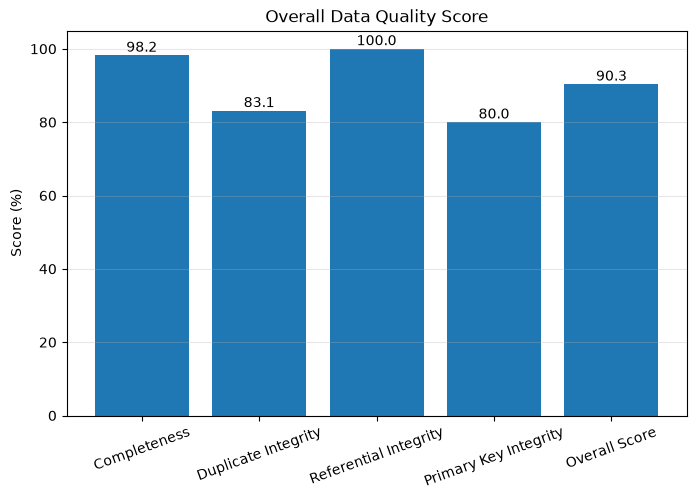

In [50]:
# ======================================================
# Data Quality Score Visualization
# ======================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    scorecard["Metric"],
    scorecard["Score"]
)

plt.title("Overall Data Quality Score")

plt.ylabel("Score (%)")

plt.xticks(rotation=20)

plt.ylim(0,105)

plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(scorecard["Score"]):

    plt.text(i, score+1, f"{score:.1f}",
             ha="center",
             fontsize=10)

plt.show()

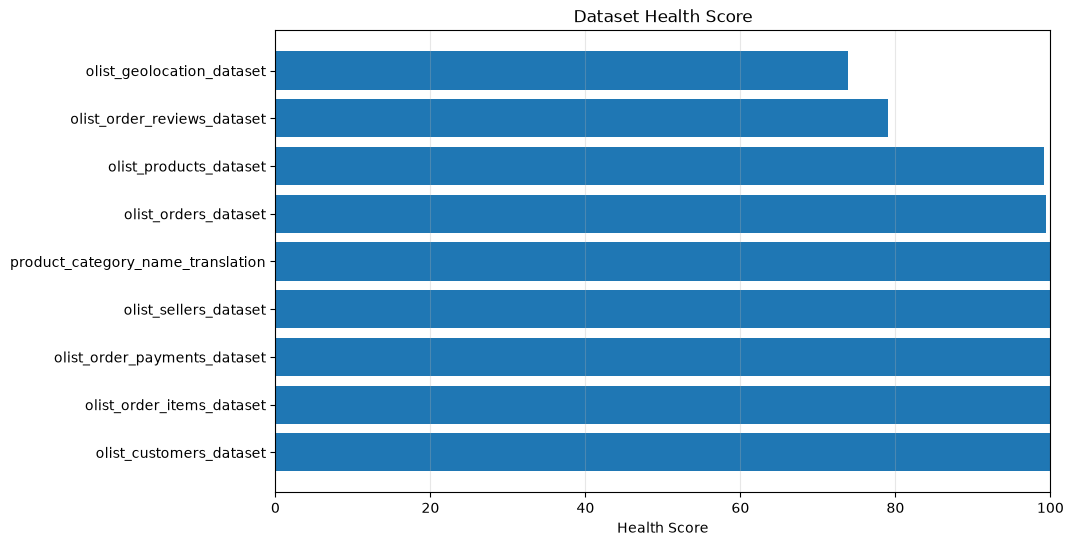

In [51]:
# ======================================================
# Dataset Health Ranking
# ======================================================

plt.figure(figsize=(10,6))

plt.barh(

    health_df["Dataset"],

    health_df["Health Score"]

)

plt.title("Dataset Health Score")

plt.xlabel("Health Score")

plt.xlim(0,100)

plt.grid(axis="x", alpha=0.3)

plt.show()

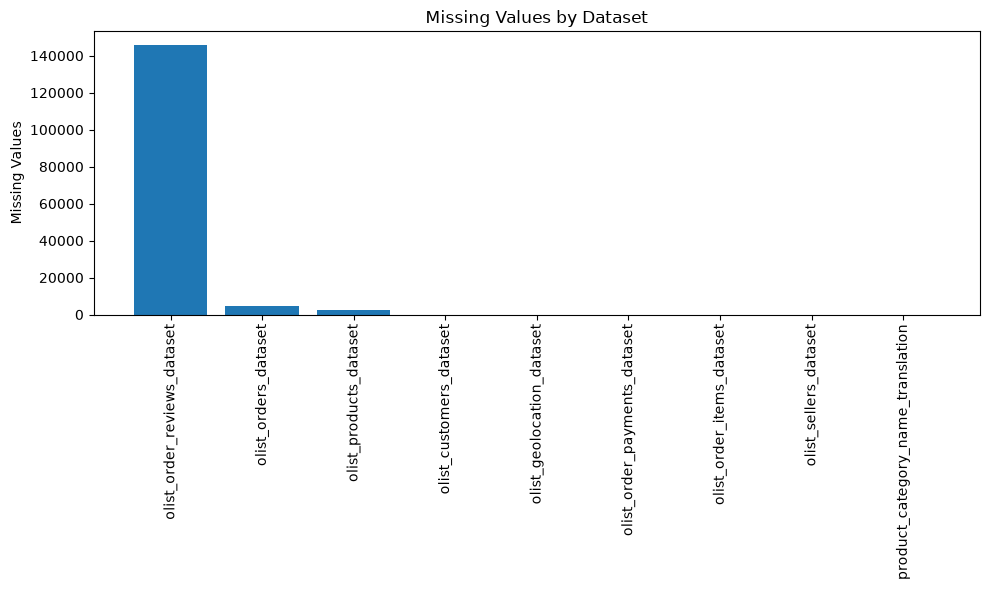

In [52]:
# ======================================================
# Missing Values by Dataset
# ======================================================

plt.figure(figsize=(10,6))

plt.bar(

    dataset_missing["Dataset"],

    dataset_missing["Missing Values"]

)

plt.xticks(rotation=90)

plt.title("Missing Values by Dataset")

plt.ylabel("Missing Values")

plt.tight_layout()

plt.show()

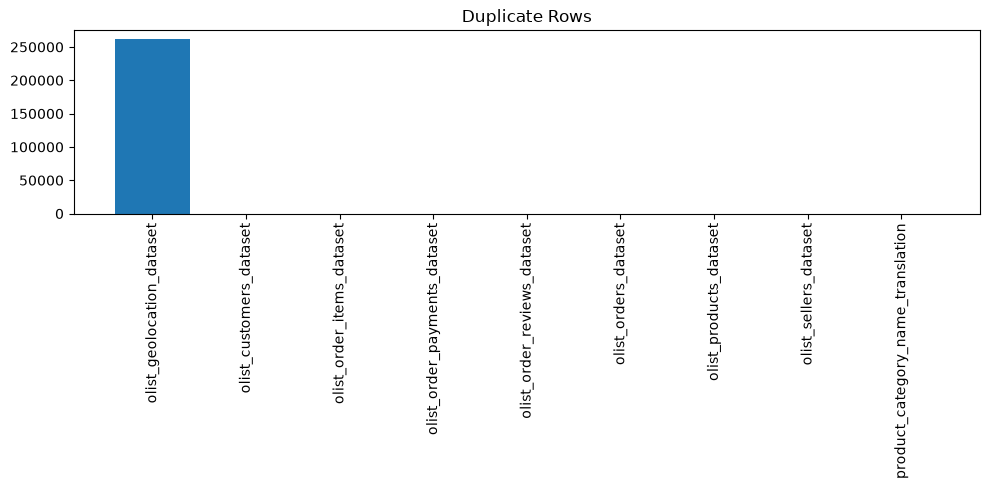

In [53]:
# ======================================================
# Duplicate Rows by Dataset
# ======================================================

plt.figure(figsize=(10,5))

plt.bar(

    duplicate_df["Dataset"],

    duplicate_df["Duplicate Rows"]

)

plt.xticks(rotation=90)

plt.title("Duplicate Rows")

plt.tight_layout()

plt.show()

In [54]:
# ======================================================
# Executive Summary
# ======================================================

executive_summary = pd.DataFrame({

    "Metric":[

        "Datasets",

        "Columns",

        "Overall Score",

        "Completeness",

        "Duplicate Score",

        "Referential Integrity",

        "Primary Key Integrity"

    ],

    "Value":[

        len(datasets),

        len(datatype_df),

        overall_score,

        completeness_score,

        duplicate_score,

        referential_score,

        pk_score

    ]

})

display(executive_summary)

,Metric,Value
0,Datasets,9.00
1,Columns,52.00
2,Overall Score,90.34
3,Completeness,98.22
4,Duplicate Score,83.12
5,Referential Integrity,100.00
6,Primary Key Integrity,80.00


In [55]:
# ======================================================
# Report Generation Summary
# ======================================================

print("="*70)
print("REPORT GENERATION SUMMARY")
print("="*70)

reports_generated = [

    "Dataset Inventory",
    "Master Profile",
    "Missing Value Report",
    "Duplicate Report",
    "Relationship Validation",
    "Executive Summary"

]

for i, report in enumerate(reports_generated, start=1):

    print(f"{i}. {report}")

print("\nAll reports successfully generated in memory.")

print("Reports will be exported in the final Reporting Notebook.")

print("="*70)

REPORT GENERATION SUMMARY
1. Dataset Inventory
2. Master Profile
3. Missing Value Report
4. Duplicate Report
5. Relationship Validation
6. Executive Summary

All reports successfully generated in memory.
Reports will be exported in the final Reporting Notebook.


In [56]:
# ======================================================
# Notebook Completion Report
# ======================================================

print("="*70)
print("RETAIL INTELLIGENCE PLATFORM")
print("NOTEBOOK 01 - DATA UNDERSTANDING")
print("="*70)

print("STATUS : COMPLETED")

print("\nModules Completed")

modules = [

    "Dataset Inventory",

    "Dataset Profiling",

    "Missing Value Analysis",

    "Duplicate Detection",

    "Primary Key Validation",

    "Composite Key Validation",

    "Referential Integrity",

    "Data Type Validation",

    "Business Rule Validation",

    "Executive Dashboard",

    "Data Quality Report"

]

for i, module in enumerate(modules, start=1):

    print(f"{i:02d}. {module}")

print("\nNext Notebook")

print("Notebook 02 - Data Cleaning")

print("="*70)

RETAIL INTELLIGENCE PLATFORM
NOTEBOOK 01 - DATA UNDERSTANDING
STATUS : COMPLETED

Modules Completed
01. Dataset Inventory
02. Dataset Profiling
03. Missing Value Analysis
04. Duplicate Detection
05. Primary Key Validation
06. Composite Key Validation
07. Referential Integrity
08. Data Type Validation
09. Business Rule Validation
10. Executive Dashboard
11. Data Quality Report

Next Notebook
Notebook 02 - Data Cleaning
